  Fig06: C-Class 耀斑 360° 相位玫瑰图 (Venus/Mars/Jupiter)
[数据] 项目根目录: /data/solar-ceos/202603二修版
[数据] 耀斑原始表: /data/solar-ceos/202603二修版/data/ready/flare_1975_2017.csv
[数据] 星历天数: 73780
[数据] C-Class 耀斑记录数: 26654
  ✅ 已绘制 (a) Venus
  ✅ 已绘制 (b) Mars
  ✅ 已绘制 (c) Jupiter


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  📄 已保存: /data/solar-ceos/202603二修版/results/04_asymmetric/Fig06_phase_rose.eps
  📄 坐标数据: /data/solar-ceos/202603二修版/results/04_asymmetric/Fig06_phase_rose.csv


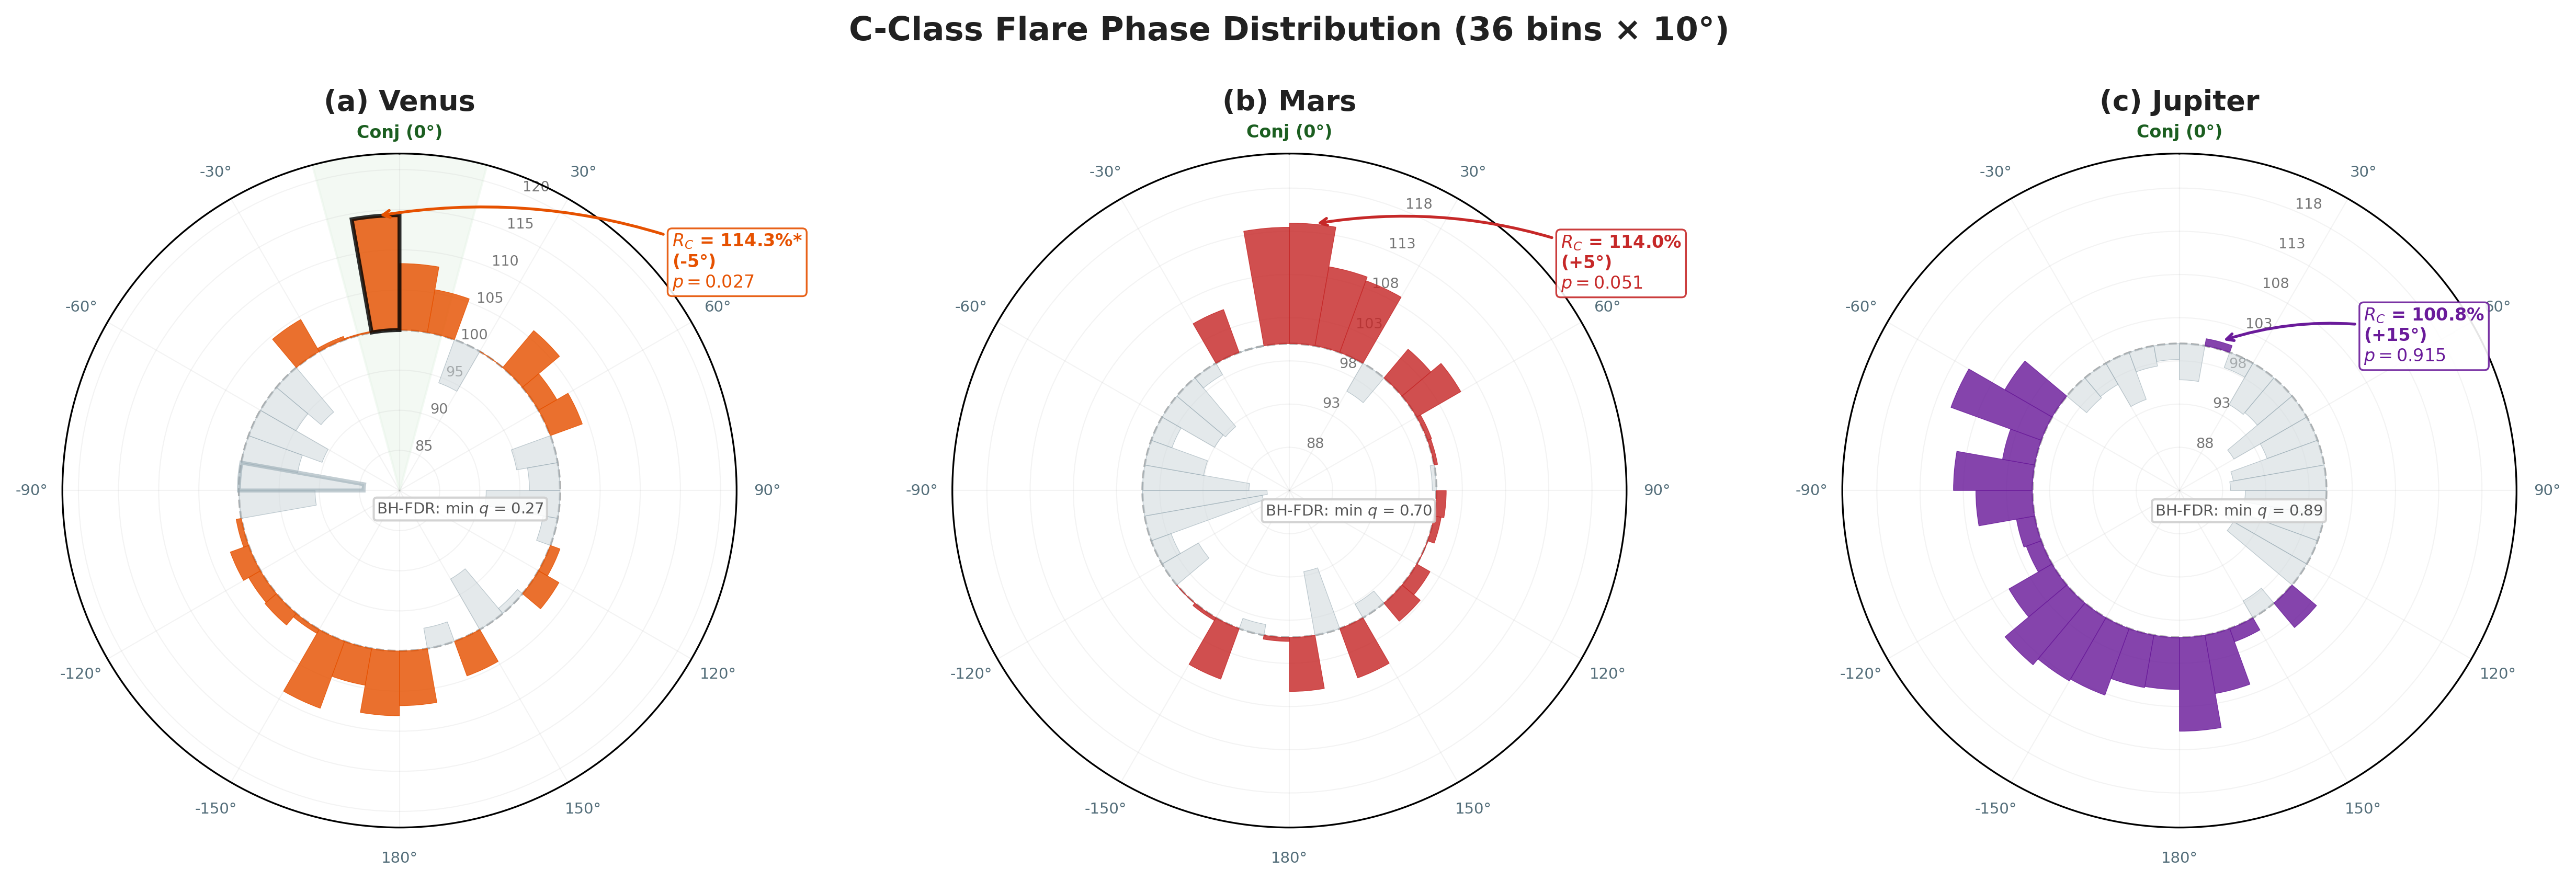


✅ Fig06 生成完成！


In [1]:
"""
Fig06: C-Class flare 360° phase rose plot (three panels)
=========================================================
直接从原始耀斑表和星历原始表计算 36×10° 相位分布，
不依赖任何预生成 phase_profile CSV。

关键: 相位 = hme_lon - planet_lon (与 CEOS 引擎一致)
      hme_lon 是耀斑在太阳表面的日心黄经，不是地球轨道经度 (399_lon)。
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ============================================================
# 路径配置
# ============================================================

def resolve_project_root():
    candidates = [
        os.getcwd(),
        os.path.abspath(os.path.join(os.getcwd(), '..', '..')),
    ]
    for cand in candidates:
        flare_csv = os.path.join(cand, 'data', 'ready', 'flare_1975_2017.csv')
        if os.path.exists(flare_csv):
            return cand
    raise FileNotFoundError('无法定位项目根目录: 缺少 data/ready/flare_1975_2017.csv')


BASE = resolve_project_root()
DATA_DIR = os.path.join(BASE, 'data', 'ready')
OUT_DIR = os.path.join(BASE, 'results', '04_asymmetric')
os.makedirs(OUT_DIR, exist_ok=True)

RAW_FLARE_CSV = os.path.join(DATA_DIR, 'flare_1975_2017.csv')
EPHEM_CANDIDATES = [
    os.path.join(DATA_DIR, '781_planets_dwarfs_asteroids_lonlat.parquet'),
    os.path.join(DATA_DIR, 'planets_satellites_lonlat.parquet'),
]

# ============================================================
# 面板配置
# ============================================================
PANELS = [
    {'planet': 'Venus',   'label': '(a) Venus',   'color_hi': '#E65100', 'color_hi_light': '#FF8A50'},
    {'planet': 'Mars',    'label': '(b) Mars',    'color_hi': '#C62828', 'color_hi_light': '#EF5350'},
    {'planet': 'Jupiter', 'label': '(c) Jupiter', 'color_hi': '#6A1B9A', 'color_hi_light': '#AB47BC'},
]

PLANET_COLS = {
    'Mercury': '199_lon',
    'Venus': '299_lon',
    'Earth': '399_lon',
    'Mars': '499_lon',
    'Jupiter': '599_lon',
    'Saturn': '699_lon',
    'Uranus': '799_lon',
    'Neptune': '899_lon',
}

COLOR_LO       = '#CFD8DC'
COLOR_LO_EDGE  = '#90A4AE'
COLOR_REF      = '#9E9E9E'
COLOR_CONJ_TXT = '#1B5E20'
COLOR_CONJ_BG  = '#E8F5E9'
SIG_EDGE_WIDTH = 1.8
NORMAL_EDGE_W  = 0.3
SIG_THRESHOLD  = 0.05
BIN_WIDTH_DEG  = 10
N_BINS         = 36
N_SIM          = 10000
CONJ_BAND_DEG  = 15
GROUP_NAME     = 'C-Class'
FIG_DPI        = 300
CTS_SEED       = 42

# ============================================================
# 辅助函数
# ============================================================

def categorize_flare(xray_class):
    if not isinstance(xray_class, str):
        return 'Other'
    c = xray_class.strip().upper()[:1]
    return f'{c}-Class' if c in 'ABCMX' else 'Other'


def interpolate_angle(a1, a2, frac):
    r1 = np.deg2rad(a1)
    r2 = np.deg2rad(a2)
    delta = (r2 - r1 + np.pi) % (2 * np.pi) - np.pi
    return np.degrees(r1 + frac * delta) % 360.0


def resolve_ephemeris_file():
    for path in EPHEM_CANDIDATES:
        if os.path.exists(path):
            return path
    raise FileNotFoundError('未找到星历原始表 (.parquet)')


def load_ephemeris():
    path = resolve_ephemeris_file()
    try:
        df_ephem = pd.read_parquet(path)
    except ImportError as exc:
        raise ImportError('读取星历 parquet 需要 pyarrow 或 fastparquet') from exc

    if 'date' not in df_ephem.columns:
        raise ValueError(f'星历表缺少 date 列: {path}')

    df_ephem['date'] = pd.to_datetime(df_ephem['date'])
    df_ephem.set_index('date', inplace=True)
    df_ephem.index = df_ephem.index.normalize()
    df_ephem = df_ephem[~df_ephem.index.duplicated(keep='first')].sort_index()

    required_cols = list(PLANET_COLS.values())
    missing = [col for col in required_cols if col not in df_ephem.columns]
    if missing:
        raise ValueError(f'星历表缺少列: {missing}')

    return df_ephem, df_ephem[required_cols].values.astype(np.float64)


def load_cclass_events(df_ephem, ephem_matrix):
    usecols = ['datetime_start', 'xray_class', 'hme_lon']
    df = pd.read_csv(RAW_FLARE_CSV, usecols=usecols)
    df['date'] = pd.to_datetime(df['datetime_start'])
    df['Group'] = df['xray_class'].apply(categorize_flare)
    df = df[df['Group'] == GROUP_NAME].copy()
    df.dropna(subset=['date', 'hme_lon'], inplace=True)
    df.drop_duplicates(subset=['date', 'xray_class', 'hme_lon'], inplace=True)

    min_date = df_ephem.index.min()
    max_date = df_ephem.index.max()
    df = df[(df['date'] >= min_date) & (df['date'] <= max_date)].copy()
    if df.empty:
        raise ValueError('过滤后没有 C-Class 耀斑记录')

    day_t = df['date'].dt.normalize()
    fraction = (df['date'] - day_t).dt.total_seconds().to_numpy() / 86400.0
    idx_t = df_ephem.index.searchsorted(day_t)

    valid_mask = idx_t < (len(df_ephem) - 1)
    if not np.all(valid_mask):
        df = df.loc[valid_mask].copy()
        idx_t = idx_t[valid_mask]
        fraction = fraction[valid_mask]

    pos_t = ephem_matrix[idx_t]
    pos_t1 = ephem_matrix[idx_t + 1]
    interp_matrix = interpolate_angle(pos_t, pos_t1, fraction[:, np.newaxis].astype(np.float64))

    df['ephem_idx_daily'] = idx_t
    interp_df = pd.DataFrame(interp_matrix, columns=list(PLANET_COLS.values()), index=df.index)
    return pd.concat([df, interp_df], axis=1)


def phase_to_bins(phase_deg):
    bins = np.floor(phase_deg / BIN_WIDTH_DEG).astype(int)
    return np.clip(bins, 0, N_BINS - 1)


def compute_phase_profile(events, ephem_daily):
    # ---- 关键: 使用 hme_lon (耀斑日心黄经), 与 CEOS 引擎一致 ----
    sun_lons = events['hme_lon'].to_numpy(dtype=np.float64)
    event_daily_idx = events['ephem_idx_daily'].to_numpy(dtype=int)
    T = len(ephem_daily)

    rng = np.random.default_rng(CTS_SEED)
    shifts = rng.integers(1, T, size=N_SIM)
    results = []

    for cfg in PANELS:
        planet = cfg['planet']
        planet_col = PLANET_COLS[planet]
        planet_idx = list(PLANET_COLS.values()).index(planet_col)

        # 观测相位: hme_lon - planet_lon (不是 earth_lon - planet_lon)
        planet_obs = events[planet_col].to_numpy(dtype=np.float64)
        phase_obs = np.mod(sun_lons - planet_obs + 180, 360) - 180  # [-180, 180]
        phase_obs_360 = np.mod(phase_obs, 360.0)  # [0, 360) for binning
        obs_bins = phase_to_bins(phase_obs_360)
        obs_counts = np.bincount(obs_bins, minlength=N_BINS)

        # CTS: 保持 hme_lon 不变, 只移位行星位置
        planet_daily = ephem_daily[:, planet_idx]
        sim_counts = np.zeros((N_SIM, N_BINS), dtype=np.int32)

        for i, shift in enumerate(shifts):
            shifted_idx = (event_daily_idx + shift) % T
            planet_shifted = planet_daily[shifted_idx]
            sim_phase = np.mod(sun_lons - planet_shifted + 180, 360) - 180
            sim_phase_360 = np.mod(sim_phase, 360.0)
            shifted_bins = phase_to_bins(sim_phase_360)
            sim_counts[i] = np.bincount(shifted_bins, minlength=N_BINS)

        exp_mean = sim_counts.mean(axis=0)
        exp_std = sim_counts.std(axis=0)

        for b in range(N_BINS):
            center = b * BIN_WIDTH_DEG + BIN_WIDTH_DEG / 2
            center_signed = center if center <= 180 else center - 360
            k_obs = int(obs_counts[b])
            k_exp = float(exp_mean[b])
            ratio = (k_obs / k_exp * 100.0) if k_exp > 0 else np.nan
            z = (k_obs - k_exp) / exp_std[b] if exp_std[b] > 0 else 0.0
            pl = (np.sum(sim_counts[:, b] <= k_obs) + 1) / (N_SIM + 1)
            pr = (np.sum(sim_counts[:, b] >= k_obs) + 1) / (N_SIM + 1)
            p_val = min(2 * min(pl, pr), 1.0)

            results.append({
                'Planet': planet,
                'Angle_Center': center_signed,
                'Ratio': round(ratio, 2),
                'Z_score': round(float(z), 2),
                'p_val': float(p_val),
            })

    df = pd.DataFrame(results)
    planet_order = {cfg['planet']: i for i, cfg in enumerate(PANELS)}
    df['_planet_order'] = df['Planet'].map(planet_order)
    return df.sort_values(['_planet_order', 'Angle_Center']).drop(columns='_planet_order').reset_index(drop=True)


def load_data():
    print(f'[数据] 项目根目录: {BASE}')
    print(f'[数据] 耀斑原始表: {RAW_FLARE_CSV}')
    df_ephem, ephem_daily = load_ephemeris()
    print(f'[数据] 星历天数: {len(df_ephem)}')
    events = load_cclass_events(df_ephem, ephem_daily)
    print(f'[数据] C-Class 耀斑记录数: {len(events)}')
    return compute_phase_profile(events, ephem_daily)


def draw_rose_panel(ax, df_planet, cfg):
    data = df_planet.sort_values('Angle_Center').copy()

    angles_deg = data['Angle_Center'].values.copy()
    angles_deg_signed = angles_deg.copy()
    angles_deg[angles_deg < 0] += 360
    theta = np.deg2rad(angles_deg)
    ratio = data['Ratio'].values
    p_vals = data['p_val'].values
    width = np.deg2rad(BIN_WIDTH_DEG)

    bg_theta = np.linspace(-np.deg2rad(CONJ_BAND_DEG), np.deg2rad(CONJ_BAND_DEG), 60)
    ax.fill_between(bg_theta, 80, 130, color=COLOR_CONJ_BG, alpha=0.5, zorder=0)

    ref_theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(ref_theta, [100] * len(ref_theta), color=COLOR_REF,
            linewidth=1.0, linestyle='--', zorder=1, alpha=0.8)

    for t, r, p in zip(theta, ratio, p_vals):
        is_above = r >= 100
        color = cfg['color_hi'] if is_above else COLOR_LO
        edge_color = cfg['color_hi'] if is_above else COLOR_LO_EDGE
        alpha = 0.82 if is_above else 0.55
        is_sig = p < SIG_THRESHOLD
        lw = SIG_EDGE_WIDTH if is_sig else NORMAL_EDGE_W
        if is_sig and is_above:
            edge_color = '#000000'

        ax.bar(t, r - 100, width=width, bottom=100,
               color=color, alpha=alpha,
               edgecolor=edge_color, linewidth=lw,
               zorder=3 if is_sig else 2)

    conj_mask = np.abs(angles_deg_signed) <= CONJ_BAND_DEG
    if conj_mask.sum() > 0:
        conj_data = data.loc[conj_mask]
        peak_row = conj_data.loc[conj_data['Ratio'].idxmax()]
        peak_angle = peak_row['Angle_Center']
        peak_ratio = peak_row['Ratio']
        peak_p = peak_row['p_val']
        pa_rad = np.deg2rad(peak_angle if peak_angle >= 0 else peak_angle + 360)

        if peak_p < 0.001:
            p_str = '$p < 0.001$'
        else:
            p_str = f'$p = {peak_p:.3f}$'

        if peak_p < 0.01:
            sig_star = '**'
        elif peak_p < 0.05:
            sig_star = '*'
        else:
            sig_star = ''

        ann_text = f'$R_C$ = {peak_ratio:.1f}%{sig_star}\n({peak_angle:+.0f}°)\n{p_str}'
        ax.annotate(
            ann_text,
            xy=(pa_rad, peak_ratio),
            xytext=(np.deg2rad(50), min(peak_ratio + 10, 125)),
            fontsize=8, fontweight='bold', color=cfg['color_hi'],
            ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color=cfg['color_hi'],
                            lw=1.3, connectionstyle='arc3,rad=0.15'),
            zorder=10,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=cfg['color_hi'], alpha=0.9, linewidth=0.8),
        )

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    r_data_max = max(ratio.max(), 115)
    r_data_min = min(ratio.min(), 88)
    r_lo = max(int(r_data_min // 5 * 5 - 2), 80)
    r_hi = int(r_data_max // 5 * 5 + 7)
    ax.set_ylim(r_lo, r_hi)

    yticks = list(range(r_lo + 5, r_hi, 5))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t}' if t != 100 else '100' for t in yticks],
                       fontsize=6.5, color='#757575')
    ax.yaxis.set_tick_params(pad=1)

    angle_labels_deg = list(range(0, 360, 30))
    ax.set_xticks(np.deg2rad(angle_labels_deg))
    labels = []
    for a in angle_labels_deg:
        if a == 0:
            labels.append('')
        elif a == 180:
            labels.append('180°')
        elif a <= 180:
            labels.append(f'{a}°')
        else:
            labels.append(f'{a-360}°')
    ax.set_xticklabels(labels, fontsize=7, color='#546E7A')

    ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_title(cfg['label'], fontsize=13, fontweight='bold', pad=20, color='#212121')
    ax.annotate('Conj (0°)', xy=(0, r_hi + 1.5), fontsize=8,
                ha='center', va='bottom', color=COLOR_CONJ_TXT,
                fontweight='bold', annotation_clip=False)


# ============================================================
# 主流程
# ============================================================

def main():
    print('=' * 60)
    print('  Fig06: C-Class 耀斑 360° 相位玫瑰图 (Venus/Mars/Jupiter)')
    print('=' * 60)

    df = load_data()
    if df.empty:
        print('❌ 未找到 Fig06 数据。')
        sys.exit(1)

    # ── 读取 FDR 校正数据 ──
    fdr_rose_path = os.path.join(BASE, 'results', '05_multidimensional', 'fdr_audit', 'fig06_phase_rose_fdr.csv')
    fdr_rose = pd.read_csv(fdr_rose_path) if os.path.exists(fdr_rose_path) else None

    fig = plt.figure(figsize=(17, 6), dpi=FIG_DPI)

    from matplotlib.gridspec import GridSpec
    gs = GridSpec(1, 3, figure=fig, left=0.04, right=0.96, bottom=0.04, top=0.85, wspace=0.32)

    for i, cfg in enumerate(PANELS):
        ax = fig.add_subplot(gs[0, i], projection='polar')
        df_p = df[df['Planet'] == cfg['planet']]
        if df_p.empty:
            print(f"  ⚠️ 缺少 {cfg['planet']} 数据")
            continue
        draw_rose_panel(ax, df_p, cfg)

        # ── FDR 标注 ──
        if fdr_rose is not None:
            planet_fdr = fdr_rose[fdr_rose['Planet'] == cfg['planet']]
            min_q = planet_fdr['q_planet'].min()
            ax.text(np.deg2rad(225), ax.get_ylim()[0] + 4,
                    f'BH-FDR: min $q$ = {min_q:.2f}',
                    fontsize=7, color='#555555',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor='#cccccc', alpha=0.85))

        print(f"  ✅ 已绘制 {cfg['label']}")

    fig.suptitle('C-Class Flare Phase Distribution (36 bins × 10°)',
                 fontsize=15, fontweight='bold', y=0.95, color='#212121')

    eps_out = os.path.join(OUT_DIR, 'Fig06_phase_rose.eps')
    fig.savefig(eps_out, bbox_inches='tight', dpi=FIG_DPI)
    print(f'  📄 已保存: {eps_out}')

    csv_out = os.path.join(OUT_DIR, 'Fig06_phase_rose.csv')
    cols = ['Planet', 'Angle_Center', 'Ratio', 'Z_score', 'p_val']
    df[cols].to_csv(csv_out, index=False)
    print(f'  📄 坐标数据: {csv_out}')

    plt.show()
    plt.close(fig)
    print('\n✅ Fig06 生成完成！')


if __name__ == '__main__':
    main()